<a href="https://colab.research.google.com/github/JulTob/Data/blob/main/Visualizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# U3.3 · Caso Práctico: Airbnb NYC (Aplicación de Pandas y Visualización) 🛠️

**Asignatura:** Técnicas de Visualización  
**Objetivo principal:** La visualización debe ser precedida por la **preparación y transformación** de los datos usando los métodos de *Pandas* aprendidos.

**Dataset:** Inside Airbnb – New York City (listings)  

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 0. Preparación y Carga de Datos

> IMPORTANTE LIMPIAR E INPUTAR LOS DATOS SIEMPRE

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración básica de visualización
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 50)

# URL del dataset (Airbnb NYC)
url = "listings.csv"

# Cargamos solo las columnas relevantes para la práctica
cols = ['id', 'name',
        'host_id',
        'neighbourhood_group',
        'room_type',
        'price',
        'minimum_nights',
        'number_of_reviews',
        'reviews_per_month',
        'calculated_host_listings_count']

try:
    df = pd.read_csv(url, usecols=cols)
    print(f"Datos cargados. Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
    display(df.head())
except Exception as e:
    print(f"Error al cargar los datos: {e}")
    # Crear un DataFrame dummy si la URL falla para que el código no rompa
    data = {'neighbourhood': ['Manhattan', 'Brooklyn', 'Queens'],
            'room_type': ['Entire home/apt', 'Private room', 'Entire home/apt'],
            'price': [150, 80, 250],
            'minimum_nights': [3, 1, 7],
            'number_of_reviews': [10, 50, 5],
            'reviews_per_month': [1.5, 3.2, np.nan]}
    df = pd.DataFrame(data)
    print("Usando DataFrame de ejemplo.")


Datos cargados. Filas: 36111, Columnas: 10


,id,name,host_id,neighbourhood_group,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count
0,2595,Skylit Studio Oasis | Midtown Manhattan Sanctuary,2845,Manhattan,Entire home/apt,240.0,30,47,0.24,3
1,6848,Only 2 stops to Manhattan studio,15991,Brooklyn,Entire home/apt,96.0,30,195,0.98,1
2,6872,Uptown Sanctuary w/ Private Bath (Month to Month),16104,Manhattan,Private room,59.0,30,1,0.02,2
3,6990,UES Beautiful Blue Room,16800,Manhattan,Private room,73.0,30,249,1.28,1
4,7064,"Amazing location! Wburg. Large, bright & tranquil",17297,Brooklyn,Private room,NaN,30,13,0.07,2


## 1. Limpieza y Creación de Columnas (NaN, Vectorización) 🧬

### Ejercicio 1.1: Manejo de Nulos (`fillna`)
La columna `reviews_per_month` tiene valores `NaN` para las propiedades que nunca han sido revisadas. Usa **`.fillna()`** para imputar estos `NaN` con el valor **0**. (Usa `inplace=True` o reasigna la columna).



In [5]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
print("NaN values in 'reviews_per_month' filled with 0.")
display(df.head())

NaN values in 'reviews_per_month' filled with 0.


,id,name,host_id,neighbourhood_group,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count
0,2595,Skylit Studio Oasis | Midtown Manhattan Sanctuary,2845,Manhattan,Entire home/apt,240.0,30,47,0.24,3
1,6848,Only 2 stops to Manhattan studio,15991,Brooklyn,Entire home/apt,96.0,30,195,0.98,1
2,6872,Uptown Sanctuary w/ Private Bath (Month to Month),16104,Manhattan,Private room,59.0,30,1,0.02,2
3,6990,UES Beautiful Blue Room,16800,Manhattan,Private room,73.0,30,249,1.28,1
4,7064,"Amazing location! Wburg. Large, bright & tranquil",17297,Brooklyn,Private room,NaN,30,13,0.07,2


### Ejercicio 1.2: Creación de Columna Derivada (Vectorización)
Crea una nueva columna booleana llamada **`es_lujoso`** usando **operaciones vectorizadas** (`>` y `.quantile()`). Esta columna debe ser `True` si el precio (`price`) es superior al **percentil 80** del precio total.

*(Pista: `df['price'].quantile(0.8)`)*


In [7]:
precio_percentil_80 = df['price'].quantile(0.8)
df['es_lujoso'] = df['price'] > precio_percentil_80

print("Nueva columna 'es_lujoso' creada.")
display(df.head())

Nueva columna 'es_lujoso' creada.


,id,name,host_id,neighbourhood_group,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,es_lujoso
0,2595,Skylit Studio Oasis | Midtown Manhattan Sanctuary,2845,Manhattan,Entire home/apt,240.0,30,47,0.24,3,False
1,6848,Only 2 stops to Manhattan studio,15991,Brooklyn,Entire home/apt,96.0,30,195,0.98,1,False
2,6872,Uptown Sanctuary w/ Private Bath (Month to Month),16104,Manhattan,Private room,59.0,30,1,0.02,2,False
3,6990,UES Beautiful Blue Room,16800,Manhattan,Private room,73.0,30,249,1.28,1,False
4,7064,"Amazing location! Wburg. Large, bright & tranquil",17297,Brooklyn,Private room,NaN,30,13,0.07,2,False


## 2. Filtrado y Distribución (`.loc` y Máscaras Booleanas) 🔎

La columna `price` tiene *outliers* extremos. Para una mejor visualización, filtraremos el *DataFrame*.

### Ejercicio 2.1: Filtrado con Máscara Compleja
Crea un *DataFrame* llamado **`df_filtrado`** que cumpla las tres condiciones siguientes (usa **`.loc[]`** y `&`/`|`):
1.  `price` es menor a 1000 USD (para eliminar el 1% superior).
2.  `room_type` es **`Entire home/apt`** (Apartamento completo).
    
3.  El alojamiento está en **'Manhattan'** **O** en **'Brooklyn'**.
    



In [12]:
df_filtrado = df.loc[
    (df['price'] < 1000) &
    (df['room_type'] == 'Entire home/apt') &
    ((df['neighbourhood_group'] == 'Manhattan') | (df['neighbourhood_group'] == 'Brooklyn'))
    ]

print("DataFrame 'df_filtrado' creado con los filtros aplicados.")
display(df_filtrado.head())


DataFrame 'df_filtrado' creado con los filtros aplicados.


,id,name,host_id,neighbourhood_group,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,es_lujoso
0,2595,Skylit Studio Oasis | Midtown Manhattan Sanctuary,2845,Manhattan,Entire home/apt,240.0,30,47,0.24,3,False
1,6848,Only 2 stops to Manhattan studio,15991,Brooklyn,Entire home/apt,96.0,30,195,0.98,1,False
7,8490,"Maison des Sirenes1,bohemian, luminous apartment",25183,Brooklyn,Entire home/apt,170.0,30,189,0.96,2,False
8,9357,Midtown Pied-a-terre,30193,Manhattan,Entire home/apt,175.0,30,58,0.30,1,False
13,12940,Charming Brownstone 3 - Near PRATT,50148,Brooklyn,Entire home/apt,151.0,30,80,0.42,1,False


### Ejercicio 2.2: Distribución de Precio Filtrado
Utiliza el *DataFrame* **`df_filtrado`** para visualizar la distribución del precio mediante un **Boxplot** o un **Violinplot** agrupado por `room_type` o `neighbourhood_group`.

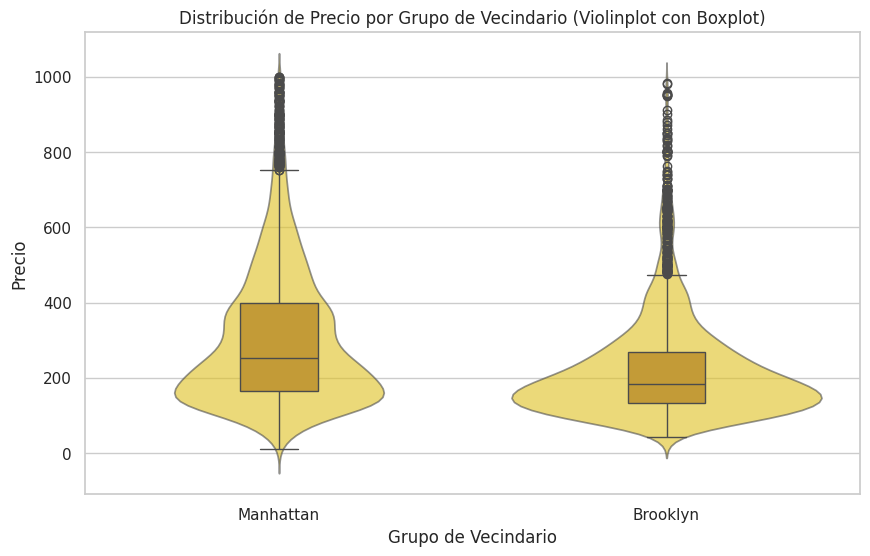

In [31]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_filtrado, x='neighbourhood_group', y='price', width=.2, color="goldenrod") # Boxplot on top with a different color
sns.violinplot(data=df_filtrado, x='neighbourhood_group', y='price', inner=None, color="gold", alpha=0.6) # Violinplot as background with adjusted alpha

plt.title('Distribución de Precio por Grupo de Vecindario (Violinplot con Boxplot)')
plt.xlabel('Grupo de Vecindario')
plt.ylabel('Precio')
plt.show()

## 3. Agrupación y Agregación (`groupby` y `agg`) 📊

Para comparar estadísticas entre categorías, es necesario resumir los datos **antes** de graficar.

### Ejercicio 3.1: Resumen Múltiple con `.agg()`
Crea un *DataFrame* llamado **`df_resumen_reviews`** utilizando **`.groupby()`** en **`room_type`** y **`.agg()`** para calcular:
1.  La **media** de `number_of_reviews` (`reviews_mean`).
2.  La **mediana** de `reviews_per_month` (`reviews_median`).
3.  El **conteo** de filas en cada grupo (`conteo`).



In [33]:
df_resumen_reviews = df.groupby('room_type').agg(
    reviews_mean=('number_of_reviews', 'mean'),
    reviews_median=('reviews_per_month', 'median'),
    conteo=('room_type', 'count')
).reset_index()

print("DataFrame 'df_resumen_reviews' creado.")
display(df_resumen_reviews)


DataFrame 'df_resumen_reviews' creado.


,room_type,reviews_mean,reviews_median,conteo
0,Entire home/apt,24.554860,0.10,19167
1,Hotel room,13.256410,0.00,351
2,Private room,30.833761,0.08,16350
3,Shared room,29.502058,0.04,243


### Ejercicio 3.2: Visualización de la Tasa de Revisión
Utiliza **`df_resumen_reviews`** para crear un **Gráfico de Barras** que muestre la **mediana de `reviews_per_month`** (`reviews_median`) por cada `room_type`.

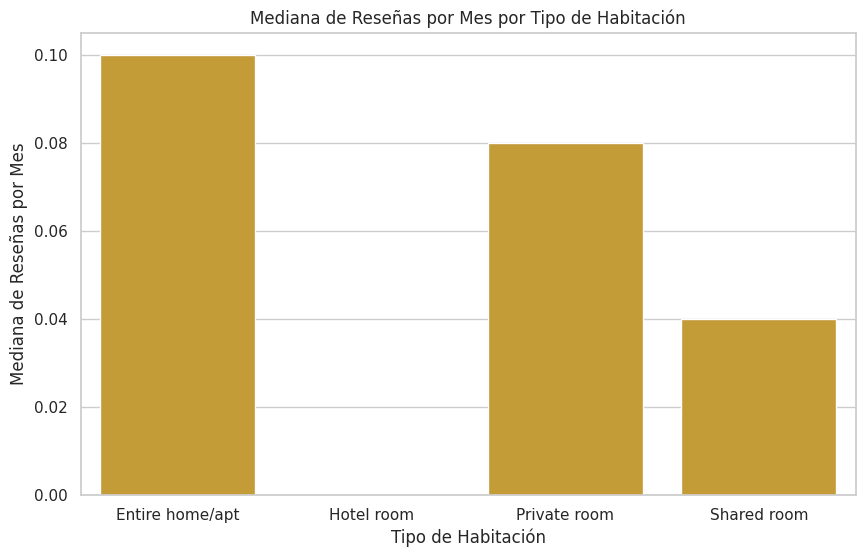

In [37]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_resumen_reviews, x='room_type', y='reviews_median', color="goldenrod")
plt.title('Mediana de Reseñas por Mes por Tipo de Habitación')
plt.xlabel('Tipo de Habitación')
plt.ylabel('Mediana de Reseñas por Mes')
plt.show()

## 4. Reorganización de Datos (`pivot_table` y `melt`) 🔄

### Ejercicio 4.1: `pivot_table` para Heatmap
Crea una tabla pivote llamada **`df_pivote_heatmap`** para mostrar la relación entre tres variables:
 * **Índice (Filas):** `room_type`
 * **Columnas:** `neighbourhood_group`
 * **Valores y Agregación:** La **mediana** de `price`.

### Ejercicio 4.2: Visualización con Heatmap
Utiliza la tabla **`df_pivote_heatmap`** directamente para generar un **`sns.heatmap`**.

### Ejercicio 4.3: `melt` para Comparación de Distribuciones
Usa **`.melt()`** en el *DataFrame* **`df`** para transformar las columnas `minimum_nights` y `number_of_reviews` en formato largo, manteniendo `room_type` como `id_vars`.
 * `var_name`: **`metrica`**
 * `value_name`: **`valor_numerico`**

### Ejercicio 4.4: Boxplot Comparativo (Melted Data)
Usa el *DataFrame* resultante de `melt` para crear un **Boxplot** que compare las distribuciones de ambas métricas (`minimum_nights` y `number_of_reviews`) en el mismo gráfico. (Filtra `valor_numerico` < 300 para limpieza si es necesario).

## 5. Conclusiones y Narrativa 📝

### Ejercicio 5.1: Redacción de *Insights*
Elige la visualización que consideres más impactante (probablemente el Heatmap o el Violinplot del precio) y redacta 3 conclusiones basadas en la evidencia visual.

1.  **Conclusión (Insight):** ¿Qué patrón o anomalía observas?  
    *Ej. Manhattan tiene los precios más altos.*
2.  **Evidencia de Datos:** ¿Qué valor(es) específico(s) en el gráfico o tabla lo respaldan?  
    *Ej. La mediana del precio para 'Entire home/apt' en Manhattan es 300, frente a 150 en Brooklyn.*
3.  **Comunicación:** ¿Cómo le explicarías esto a un inversor o a alguien no técnico?  
    *Ej. Si quieres un apartamento completo, Manhattan duplica el costo de las otras zonas; invierte en las zonas exteriores para mayor rentabilidad por volumen.*

---  
### Checklist de Buenas Prácticas de Visualización
- ✔ Gráfico adecuado al tipo de datos (Distribución, Comparación, Relación).  
- ✔ Títulos claros y descriptivos.  
- ✔ Ejes etiquetados y con unidades.  
- ✔ Leyendas claras (si aplica).  
- ✔ Uso de color con propósito (sin exceso).  


# np.where

# np.where

`np.where` is a function in the NumPy library that allows you to select elements from two arrays based on a condition. It's a vectorized way to perform conditional assignments, similar to an if-else statement.

The basic syntax is:
`numpy.where(condition, x, y)`

- **condition**: A boolean array or condition. Where this condition is True, elements from `x` are chosen.
- **x**: Values to choose when the condition is True.
- **y**: Values to choose when the condition is False.

It's particularly useful for creating new columns in a Pandas DataFrame based on values in existing columns, often more efficiently than using a loop.

**Example:**